Dataset link 
https://www.kaggle.com/datasets/architsharma01/loan-approval-prediction-dataset

In [184]:
import pandas as pd,numpy as np 
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [185]:
data_path=Path("./loan_approval_dataset.csv")

In [186]:
print("Data Set exists:", data_path.exists())

Data Set exists: True


In [187]:
df=pd.read_csv(data_path)

In [188]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [189]:
df.shape

(4269, 13)

In [190]:
df.columns.tolist()

['loan_id',
 ' no_of_dependents',
 ' education',
 ' self_employed',
 ' income_annum',
 ' loan_amount',
 ' loan_term',
 ' cibil_score',
 ' residential_assets_value',
 ' commercial_assets_value',
 ' luxury_assets_value',
 ' bank_asset_value',
 ' loan_status']

In [191]:
#fixing the column names 
df.columns=df.columns.str.strip()

In [192]:
df.columns.tolist()

['loan_id',
 'no_of_dependents',
 'education',
 'self_employed',
 'income_annum',
 'loan_amount',
 'loan_term',
 'cibil_score',
 'residential_assets_value',
 'commercial_assets_value',
 'luxury_assets_value',
 'bank_asset_value',
 'loan_status']

In [193]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [194]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [195]:
target_col='loan_status'

Using the target column: loan_status


loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

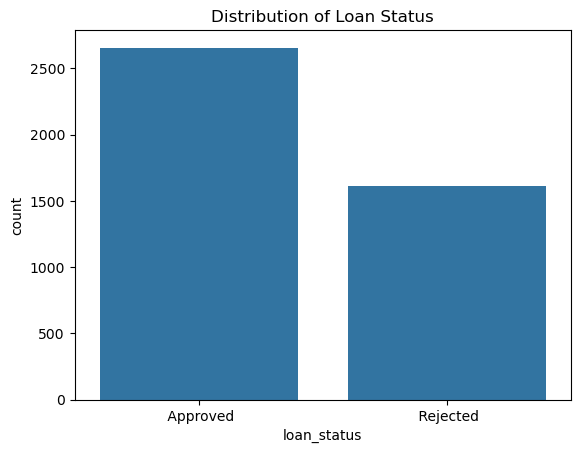

In [196]:
print("Using the target column:", target_col)
display(df[target_col].value_counts(dropna=False))
sns.countplot(x=target_col, data=df)
plt.title("Distribution of Loan Status")
plt.show()

In [197]:
df=df.drop(columns=["loan_id"],errors="ignore")

In [198]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [199]:
df_clf=df.dropna(subset=[target_col]).copy()

In [200]:
X=df_clf.drop(columns=[target_col])
y=df_clf[target_col]

In [201]:
X.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000


#Feature types

In [202]:
cat_cols=X.select_dtypes(include=["object","category"]).columns.to_list()
num_cols=X.select_dtypes(include=[np.number]).columns.to_list()

In [203]:
print("Categorical columns:", cat_cols )
print("Numerical columns:", num_cols )

Categorical columns: ['education', 'self_employed']
Numerical columns: ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']


In [204]:
#preprocessing pipeline 

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [205]:
numerical_transformer=Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
])  

In [206]:
categprical_transformer=Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="most_frequent")),    
    ("onehot",OneHotEncoder(handle_unknown="ignore"))
])

In [207]:
preprocessor=ColumnTransformer( transformers=[
    ("num",numerical_transformer,num_cols),
    ("cat",categprical_transformer,cat_cols)
],remainder='drop'
   
)

In [208]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


In [209]:
X.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000


In [210]:
y.head()

0     Approved
1     Rejected
2     Rejected
3     Rejected
4     Rejected
Name: loan_status, dtype: object

In [211]:
unique_vals=sorted(y.unique())
unique_vals

[' Approved', ' Rejected']

In [212]:
y=df_clf[target_col].astype(str).str.strip().str.lower()

In [213]:
unique_vals=sorted(y.unique())
unique_vals

['approved', 'rejected']

In [214]:
y=(y=="approved").astype(int)

In [215]:
unique_vals=sorted(y.unique())
unique_vals

[0, 1]

In [216]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [217]:
print("Train size:", x_train.shape)
print("Test size:", x_test.shape)

Train size: (3415, 11)
Test size: (854, 11)


In [218]:
#Random forest base pipeline 
from sklearn.ensemble import RandomForestClassifier

rf_clf_pipeline= Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("rf_clf",RandomForestClassifier(random_state=42))
])


In [219]:
from sklearn.model_selection import GridSearchCV
param_grid={
    "rf_clf__n_estimators":[100,200,300,400],
    "rf_clf__max_depth":[None,4,8,10],
    "rf_clf__min_samples_split":[2,5],
    "rf_clf__min_samples_leaf":[1,2] }

In [220]:
grid=GridSearchCV(estimator=rf_clf_pipeline,param_grid=param_grid,cv=5,scoring='f1',n_jobs=-1,verbose=2)
grid.fit(x_train,y_train)
print("Best parameters:", grid.best_params_)

best_clf=grid.best_estimator_
print("Best F1 Score:", grid.best_score_)

y_pred_best=best_clf.predict(x_test)

Fitting 5 folds for each of 64 candidates, totalling 320 fits
Best parameters: {'rf_clf__max_depth': None, 'rf_clf__min_samples_leaf': 1, 'rf_clf__min_samples_split': 2, 'rf_clf__n_estimators': 200}
Best F1 Score: 0.984997219900243


In [221]:
print(classification_report(y_test,y_pred_best))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       323
           1       0.98      0.98      0.98       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



In [222]:
rf_clf_pipeline=Pipeline(steps=
    [
        ("preprocessor", preprocessor),
        ("rf_clf", RandomForestClassifier(n_estimators=200,
                                          random_state=42, min_samples_split=2, min_samples_leaf=1, max_depth=None,oob_score=True
                                
                        )) 
    ]
)


In [223]:
rf_clf_pipeline.fit(x_train,y_train)
y_pred_cls=rf_clf_pipeline.predict(x_test)
print(classification_report(y_test,y_pred_cls))


              precision    recall  f1-score   support

           0       0.98      0.98      0.98       323
           1       0.98      0.98      0.98       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



In [224]:
rf_clf_pipeline 

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['no_of_dependents',
                                                   'income_annum',
                                                   'loan_amount', 'loan_term',
                                                   'cibil_score',
                                                   'residential_assets_value',
                                                   'commercial_assets_value',
                                                   'luxury_assets_value',
                                                   'bank_asset_value']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['education',
                                                   'self_employed'])])),
                ('rf_clf',
                 RandomForestClassifier(n_estimators=200, oob_score=True,
                                        random_state=42))])

In [225]:
#checking feature importance 
feature_importance=rf_clf_pipeline.named_steps["rf_clf"].feature_importances_
feature_importance

array([0.00918244, 0.0195426 , 0.03092916, 0.06148679, 0.79553633,
       0.01925474, 0.01910817, 0.019452  , 0.01685694, 0.00225723,
       0.00192051, 0.00227962, 0.00219348])

Text(0.5, 1.0, 'Top 20 Feature Importances')

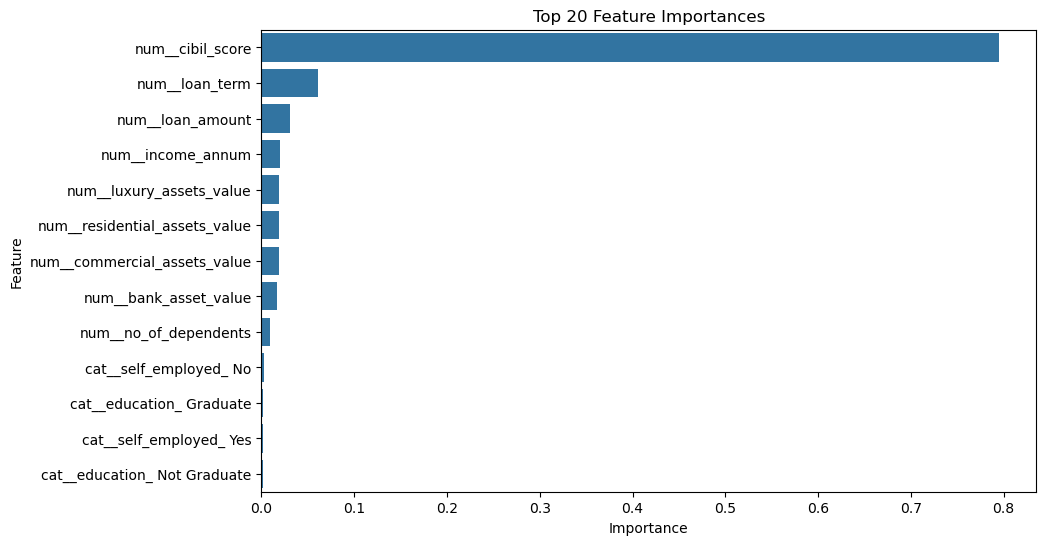

In [226]:
preprocessor=rf_clf_pipeline.named_steps["preprocessor"]
feature_names=preprocessor.get_feature_names_out()
feature_names.tolist()

importance_df=pd.DataFrame({"Feature":feature_names,"Importance":feature_importance}).sort_values(by="Importance",ascending=False)  
importance_df.head(20)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance",y="Feature",data=importance_df.head(20))
plt.title("Top 20 Feature Importances")

#stage 2 - Regression stage 

In [227]:
df["loan_status"].unique()

array([' Approved', ' Rejected'], dtype=object)

In [228]:
df["loan_status"]=df["loan_status"].str.strip().str.lower()

In [229]:
df["loan_status"].unique()

array(['approved', 'rejected'], dtype=object)

In [233]:
approved_df=df[df["loan_status"]=="approved"].copy()

In [234]:
approved_df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,approved
6,5,Graduate,No,8700000,33000000,4,678,22500000,14800000,29200000,4300000,approved
8,0,Graduate,Yes,800000,2200000,20,782,1300000,800000,2800000,600000,approved
10,4,Graduate,Yes,2900000,11200000,2,547,8100000,4700000,9500000,3100000,approved
13,2,Graduate,Yes,9100000,31500000,14,679,10800000,16600000,20900000,5000000,approved


In [236]:
reg_target="loan_amount"
reg_df=approved_df.dropna(subset=[reg_target]).copy()


In [237]:
x_reg=reg_df.drop(columns=[reg_target])
y_reg=reg_df[reg_target]

In [238]:
cat_cols_reg=x_reg.select_dtypes(include=["object","category"]).columns.to_list()
num_cols_reg=x_reg.select_dtypes(include=[np.number]).columns.to_list()

In [239]:
print("Categorical columns for regression:", cat_cols_reg)
print("Numerical columns for regression:", num_cols_reg)

Categorical columns for regression: ['education', 'self_employed', 'loan_status']
Numerical columns for regression: ['no_of_dependents', 'income_annum', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']


In [240]:
x_train_reg, x_test_reg, y_train_reg, y_test_reg = train_test_split(x_reg, y_reg, test_size=0.2, random_state=42)
print("Train size:", x_train_reg.shape)
print("Test size:", x_test_reg.shape)

Train size: (2124, 11)
Test size: (532, 11)


In [244]:
preprocessor=ColumnTransformer( transformers=[
    ("num",numerical_transformer,num_cols_reg),
    ("cat",categprical_transformer,cat_cols_reg)
],remainder='drop'
   
)